# 06: Lab - Data Scraping

This practice notebook provides additional preparation for Assignment 6. 

## Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`)
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [1]:
#Import packages
import pandas as pd

#Web scraping
import requests
from bs4 import BeautifulSoup

#Automation tools
import time
from itertools import product

#Plotting
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

#Set Seaborn theme
sns.set_theme(style="whitegrid", context="notebook")

## Scraping Exercises

### 1. Scrape 2024 electricity usage data from the EIA 
Let's scrape data the US Energy Administration's State Electricity Archive:
<https://www.eia.gov/electricity/state/>

1. Navigate to the page. Note the year for which these data are provided.
2. Use the Selector Gadget tool to scrape the following values into variables: 
    * State name
    * Average Retail price
    * Net summer capacity
    * Net generation
    * Total retail sales
3. Compile the data into a dataframe
4. Examine the dataframe

**Recall that the BeautifulSoup scraping workflow is as follows**: 
1. Retrieve to the website contents using the `requests.get()` function.
1. Parse the contents into "soup" using BeautifulSoup.
1. Extract specific elements--or *element sets*--in the web site via their node IDs, found using Selector Gadget
    - Convert into lists using list comprehension<br>*Hint:* `[items.get_text(strip=True) for items in the_website.select('<nodeID>')]`
1. Wrangle values into a dataframe
    - Note that scraped values are always returned as strings; you'll need to manually convert these to numeric values (`float` or `int`)
    - Also note that with numbers scraped with a comma separator (e.g. `1,000`), the comma needs to be removed;  `str.replace(',','')` is helpful here
1. Examine the column information for your dataframe.
1. [Optional] Construct a regression plot (`regplot`) showing the relationship of total retail sales to net generation of electricity. 

In [ ]:
# 1.1 Fetch and parse the website
url='https://www.eia.gov/electricity/state/'

response=requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")
type(webpage)

if webpage.title: 
    print(webpage.title.get_text(strip=True))
else: print("no page title")

# 1.2 Locate elements and read their text attributes into variables
state_names = [items.get_text(strip=True) for items in webpage.select("td:nth-child(1)")]
avg_price =  [items.get_text(strip=True) for items in webpage.select("td:nth-child(2)")]
net_sum_cap = [items.get_text(strip=True) for items in webpage.select("td:nth-child(3)")]
net_generation =  [items.get_text(strip=True) for items in webpage.select("td:nth-child(4)")]
total_sales =  [items.get_text(strip=True) for items in webpage.select("td:nth-child(5)")]


# 1.3 Construct a dataframe from the values
eia_df = pd.DataFrame({
    "State Name": state_names,
    "Average Retail Price": avg_price,
    "Net Summer Capacity": net_sum_cap,
    "Net Generation": net_generation,
    "Total Retail Sales": total_sales
}).iloc[:-1] # remove the last row, which has summary data we don't need

# 1.4 Wrangle - put into readable forms, eg not strings
eia_df["Average Retail Price"]=eia_df["Average Retail Price"].astype('float')
eia_df["Net Summer Capacity"]=eia_df["Net Summer Capacity"].str.replace(',','').astype('int') # have to get rid of commas to convert to int
eia_df["Net Generation"]=eia_df["Net Generation"].str.replace(',','').astype('int')
eia_df["Total Retail Sales"]=eia_df["Total Retail Sales"].str.replace(',','').astype('int')


# 1.5 Examine
eia_df.info()

# 1.6. Plot
# skipping plot bc of kernel crash

US Electricity Profile
		2024 -
		U.S. Energy Information Administration (EIA)
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State Name            51 non-null     str    
 1   Average Retail Price  51 non-null     float64
 2   Net Summer Capacity   51 non-null     int64  
 3   Net Generation        51 non-null     int64  
 4   Total Retail Sales    51 non-null     int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 2.1 KB


### 2. Repeat, for a different year
* Copy and paste your code in the code chunk below, then modify it to fetch the same data for 2023
    - Note that the URL takes a slightly different format than 2024, but the HTML tags remain the same. 

In [13]:
#Copy and paste code from above; then modify to scrape data for 2023
# 1.1 Fetch and parse the website
url='https://www.eia.gov/electricity/state/archive/2023'

response=requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")
type(webpage)

if webpage.title: 
    print(webpage.title.get_text(strip=True))
else: print("no page title")

# 1.2 Locate elements and read their text attributes into variables
state_names = [items.get_text(strip=True) for items in webpage.select("td:nth-child(1)")]
avg_price =  [items.get_text(strip=True) for items in webpage.select("td:nth-child(2)")]
net_sum_cap = [items.get_text(strip=True) for items in webpage.select("td:nth-child(3)")]
net_generation =  [items.get_text(strip=True) for items in webpage.select("td:nth-child(4)")]
total_sales =  [items.get_text(strip=True) for items in webpage.select("td:nth-child(5)")]


# 1.3 Construct a dataframe from the values
eia_df = pd.DataFrame({
    "State Name": state_names,
    "Average Retail Price": avg_price,
    "Net Summer Capacity": net_sum_cap,
    "Net Generation": net_generation,
    "Total Retail Sales": total_sales
}).iloc[:-1] # remove the last row, which has summary data we don't need

# 1.4 Wrangle - put into readable forms, eg not strings
eia_df["Average Retail Price"]=eia_df["Average Retail Price"].astype('float')
eia_df["Net Summer Capacity"]=eia_df["Net Summer Capacity"].str.replace(',','').astype('int') # have to get rid of commas to convert to int
eia_df["Net Generation"]=eia_df["Net Generation"].str.replace(',','').astype('int')
eia_df["Total Retail Sales"]=eia_df["Total Retail Sales"].str.replace(',','').astype('int')


# 1.5 Examine
eia_df.info()


US Electricity Profile
		2023 -
		U.S. Energy Information Administration (EIA)
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State Name            51 non-null     str    
 1   Average Retail Price  51 non-null     float64
 2   Net Summer Capacity   51 non-null     int64  
 3   Net Generation        51 non-null     int64  
 4   Total Retail Sales    51 non-null     int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 2.1 KB


### 3. Create a scraping *function* to accept a year as the input
* Note, you'll need to add an `if` statement to check whether the year is 2024 or not as the URL changes for years before 2024
* Add a `year` column to the dataframe, setting its value to the year supplied when the function is called. 

In [ ]:
# 3. Create a scrape function
def scrape_it(the_year):

    # 3.1 Form the base url based on whether the year is 2024 or not
    if the_year==2024:
        url='https://www.eia.gov/electricity/state/'
    else:
        url=

    # 3.2 Fetch & parse the website


    # 3.3 Extract the data to list variables


    # 3.4 Construct a dataframe from the extracted list variables


    # 3.5 Wrangle as needed


    # 3.6 Return the dataframe


### 4. Use the function to scrape data for 2017

In [16]:
#Use the function to scrape data for 2017
df_2017 = scrape_it(2017)
df_2017.head()

,state,price_USD,capacity_MW,net_generation_MWh,total_retail_MWh,year
0,Alabama,9.83,29725,139964250,86241730,2017
1,Alaska,19.10,2749,6497466,6185799,2017
2,Arizona,10.64,28595,105851721,77646262,2017
3,Arkansas,8.26,14642,60775298,46085951,2017
4,California,16.06,76414,206146392,257267937,2017


### 5. Use the function to scrape data for 2017-2024
* Construct dataframes for each year
* Concatenate the dataframes into a single dataframe
* Plot electricity prices for Virginia, North Carolina, and South Carolina for the span 2017-2024

In [17]:
# 5.1 Extract and concatenate the dataframes
df_range = pd.concat(
    [scrape_it(the_year) for the_year in range(2017,2025)]
)

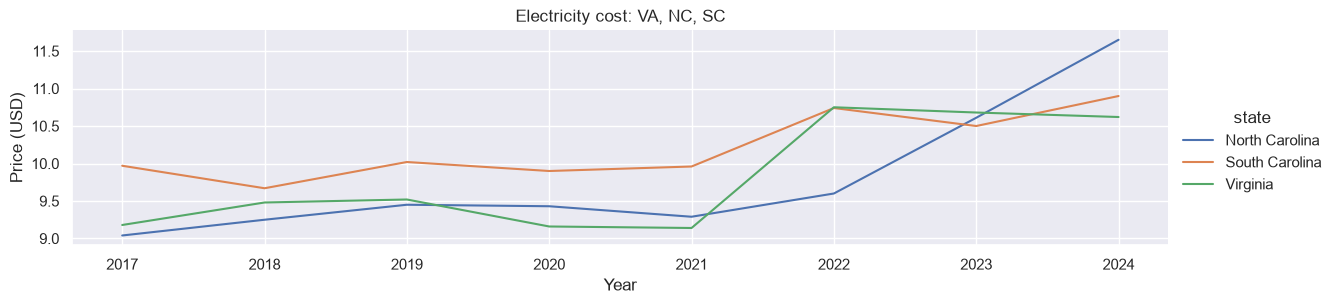

In [18]:
# 5.2 Plot electricity cost for VA, NC, SC
sns.relplot(
    data=df_range[df_range['state'].isin(['Virginia','North Carolina','South Carolina'])],
    x='year',
    y='price_USD',
    hue='state',
    kind='line',
    height=3,
    aspect=4
).set(
    title='Electricity cost: VA, NC, SC',
    xlabel='Year',
    ylabel='Price (USD)'
);